<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/Cats%20%26%20Dogs%20Classification%3A%20A%20Comparative%20Study%20of%20Custom%20CNN%20and%20VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐱🐶 Kedi–Köpek Sınıflandırma — Derin Öğrenme Detaylı Anlatım

Bu notebook, CNN ile görüntü sınıflandırmanın **her adımını**, **neden yaptığımızı** ve **kodun ne anlama geldiğini** açıklamaktadır.

---
## 📋 İçindekiler

| # | Konu |
|---|------|
| 1 | Temel Kavramlar ve Neden Derin Öğrenme? |
| 2 | Kütüphaneler ve Kurulum |
| 3 | Veri Hazırlama ve Ön İşleme |
| 4 | Normalizasyon — Neden Gerekli? |
| 5 | Data Augmentation — Veri Artırma |
| 6 | Evrişim (Convolution) — Teorik Açıklama |
| 7 | MaxPooling, BatchNorm, Dropout |
| 8 | CNN Mimarisi — Katman Katman Analiz |
| 9 | Transfer Learning — VGG16 |
| 10 | Kayıp Fonksiyonu ve Optimizer |
| 11 | Callback'ler — Akıllı Eğitim Kontrolü |
| 12 | Eğitim Döngüsü |
| 13 | Değerlendirme Metrikleri |
| 14 | Görselleştirme |
| 15 | Tek Görüntü Tahmini |
| 16 | Özet ve Sık Yapılan Hatalar |

---
## 1. Temel Kavramlar — Neden Derin Öğrenme?

### Geleneksel Yöntem vs Derin Öğrenme

**Geleneksel görüntü işleme:**
- Özellikleri *insan* tanımlar: "Kedi sivri kulağa sahiptir, bıyığı vardır..."
- HOG, SIFT, LBP gibi elle tasarlanmış özellik çıkarıcılar kullanılır
- Sınırlı genelleme kapasitesi

**Derin Öğrenme (CNN):**
- Özellikleri *ağ* kendi başına öğrenir
- İlk katmanlar: kenarlar, köşeler, renkler
- Orta katmanlar: dokular, şekiller
- Derin katmanlar: kulak, burun, göz gibi karmaşık yapılar
- Veri arttıkça performans artar

### CNN'in Temel Bileşenleri

```
Görüntü Girişi
     ↓
Conv2D (Özellik Çıkarımı)
     ↓
BatchNorm + ReLU (Stabilite + Doğrusal Olmayanlık)
     ↓
MaxPooling (Boyut Azaltma)
     ↓
Dropout (Düzensizleştirme)
     ↓
  [tekrar et...]
     ↓
Global Average Pooling (Vektöre Dönüştür)
     ↓
Dense (Tam Bağlantılı Sınıflandırıcı)
     ↓
Sigmoid → P(köpek) ∈ [0, 1]
```

### İkili Sınıflandırma Mantığı

- Çıkış: Tek nöron, sigmoid aktivasyonu
- `P(köpek) ≥ 0.5` → **Köpek** 🐶
- `P(köpek) < 0.5`  → **Kedi**  🐱
- `P(köpek) = 0.95` → %95 güvenle köpek
- `P(köpek) = 0.51` → zayıf güvenle köpek (sınırda örnek)

---
## 2. Kütüphaneler — Ne İşe Yararlar?


In [1]:
# ── Kurulum ────────────────────────────────────────────────────
!pip install tensorflow numpy matplotlib scikit-learn opencv-python Pillow seaborn -q

In [2]:
# ── Kütüphane Açıklamaları ─────────────────────────────────────

import os
import random
import numpy as np              # Sayısal işlemler, dizi/matris operasyonları
import matplotlib.pyplot as plt # Görselleştirme (grafik, histogram, resim gösterimi)
import seaborn as sns           # İstatistiksel görselleştirme (confusion matrix ısı haritası)
import cv2                      # OpenCV — görüntü okuma, yeniden boyutlandırma, renk dönüşümü
from PIL import Image, ImageDraw  # Pillow — sentetik görüntü üretimi
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
# layers   → Conv2D, Dense, Dropout vb. katman nesneleri
# models   → Sequential ve Functional API
# optimizers → Adam, SGD vb.
# callbacks → EarlyStopping, ReduceLROnPlateau vb.

from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Görüntü artırma ve batch akışı için

from tensorflow.keras.applications import VGG16
# ImageNet üzerinde eğitilmiş hazır model (transfer learning)

from sklearn.model_selection import train_test_split
# Veri setini eğitim/doğrulama/test'e bölmek için

from sklearn.metrics import (
    classification_report,  # Precision, Recall, F1 raporu
    confusion_matrix,        # Tahmin hataları matrisi
    roc_auc_score,           # ROC eğrisi altındaki alan
    roc_curve                # ROC eğrisi noktaları
)

# ── Tekrarlanabilirlik ─────────────────────────────────────────
# Aynı sonuçları her çalıştırmada elde etmek için sabit tohum
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Donanım Kontrolü ───────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU Sayısı : {len(gpus)}")
print(f"Cihaz      : {'GPU ⚡' if gpus else 'CPU (GPU yoksa eğitim yavaş olabilir)'}")

TensorFlow : 2.20.0
GPU Sayısı : 1
Cihaz      : GPU ⚡


---
## 3. Veri Hazırlama ve Ön İşleme

### Temel İşlem Akışı

```
Ham Görüntü (farklı boyutlar)
       ↓  cv2.imread()
  BGR Dizisi
       ↓  cvtColor(BGR→RGB)
  RGB Dizisi
       ↓  cv2.resize(128,128)
  128×128×3 Numpy Dizisi
       ↓  / 255.0
  Normalize Görüntü [0.0, 1.0]
       ↓  train_test_split
  Eğitim / Doğrulama / Test
```

### Neden BGR → RGB Dönüşümü?
OpenCV görüntüleri varsayılan olarak **BGR** sırasında okur (tarihsel sebep).  
TensorFlow ve matplotlib **RGB** bekler.  
Dönüşüm yapmazsak renkler yanlış görünür ve model yanlış öğrenir.

In [3]:
# ── Ayarlar ────────────────────────────────────────────────────
IMG_SIZE      = 128      # Tüm görüntüler 128×128 piksele getirilir
BATCH_SIZE    = 32       # Her adımda 32 görüntü işlenir
EPOCHS        = 20       # Maksimum epoch sayısı (EarlyStopping devrede)
USE_REAL_DATA = False    # True → kendi veri setini kullan
DATA_DIR      = './data' # Gerçek veri klasörü (kedi/ ve köpek/ alt klasörleri)
CLASSES       = ['kedi', 'köpek']

print("Ayarlar:")
print(f"  Görüntü boyutu : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Batch büyüklüğü: {BATCH_SIZE}")
print(f"  Max epoch      : {EPOCHS}")
print(f"  Veri modu      : {'Gerçek Veri' if USE_REAL_DATA else 'Sentetik Veri'}")

Ayarlar:
  Görüntü boyutu : 128×128
  Batch büyüklüğü: 32
  Max epoch      : 20
  Veri modu      : Sentetik Veri


In [4]:
# ── Sentetik Veri Üreteci ─────────────────────────────────────
# Gerçek veri yokken algoritmayı test etmek için kullanılır.
# Basit geometrik şekillerle kedi ve köpek temsil edilir.

def generate_synthetic_image(label: int, size: int = 128) -> np.ndarray:
    """
    label=0 → Kedi: yuvarlak kafa, sivri kulaklar, bıyıklar
    label=1 → Köpek: dikdörtgen kafa, sarkık kulaklar, büyük burun
    """
    # Açık gri arka plan
    img = Image.new('RGB', (size, size),
                    color=(random.randint(180, 220),
                           random.randint(180, 220),
                           random.randint(180, 220)))
    draw = ImageDraw.Draw(img)
    cx, cy = size // 2, size // 2   # Merkez koordinatı

    if label == 0:  # ── Kedi ──────────────────────────────────
        r = size // 4
        color = (random.randint(100, 160), random.randint(60, 100), 30)
        # Yuvarlak kafa
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=color)
        # Sivri üçgen kulaklar (kediye özgü)
        draw.polygon([(cx-r, cy-r), (cx-r+12, cy-r-22), (cx-r+24, cy-r)], fill=color)
        draw.polygon([(cx+r-24, cy-r), (cx+r-12, cy-r-22), (cx+r, cy-r)], fill=color)
        # Yeşil gözler
        draw.ellipse([cx-14, cy-8, cx-4, cy+2], fill=(50, 180, 50))
        draw.ellipse([cx+4,  cy-8, cx+14, cy+2], fill=(50, 180, 50))
        # Bıyıklar (yatay çizgiler)
        for dy in [-2, 2]:
            draw.line([(cx-r, cy+10+dy), (cx-5, cy+10+dy)], fill=(0,0,0), width=1)
            draw.line([(cx+5, cy+10+dy), (cx+r, cy+10+dy)], fill=(0,0,0), width=1)

    else:           # ── Köpek ─────────────────────────────────
        rw, rh = size // 3, size // 4
        color = (random.randint(130, 180), random.randint(80, 120), 40)
        # Dikdörtgenimsi kafa (yuvarlak köşeli)
        draw.rounded_rectangle([cx-rw, cy-rh, cx+rw, cy+rh], radius=16, fill=color)
        # Sarkık oval kulaklar (köpeğe özgü)
        draw.ellipse([cx-rw-14, cy-rh+4, cx-rw+8, cy+rh-4], fill=(100,60,20))
        draw.ellipse([cx+rw-8,  cy-rh+4, cx+rw+14, cy+rh-4], fill=(100,60,20))
        # Koyu kahve gözler
        draw.ellipse([cx-16, cy-8, cx-4, cy+4], fill=(80,50,20))
        draw.ellipse([cx+4,  cy-8, cx+16, cy+4], fill=(80,50,20))
        # Büyük burun
        draw.ellipse([cx-8, cy+8, cx+8, cy+18], fill=(40,20,10))

    # Gerçekçilik için rastgele Gaussian gürültü ekle
    arr = np.array(img, dtype=np.float32)
    arr += np.random.normal(0, 8, arr.shape)
    return np.clip(arr, 0, 255).astype(np.uint8)


def load_synthetic_data(n_per_class: int = 500):
    """Her sınıftan n_per_class adet görüntü üretir."""
    X, y = [], []
    for label in [0, 1]:
        for _ in range(n_per_class):
            X.append(generate_synthetic_image(label, IMG_SIZE))
            y.append(label)
    # Karıştır (önce hepsi kedi, sonra hepsi köpek olmasın)
    combined = list(zip(X, y))
    random.shuffle(combined)
    X, y = zip(*combined)
    return np.array(X), np.array(y)


# ── Gerçek Veri Yükleyici ──────────────────────────────────────
def load_real_data(data_dir: str, img_size: int = 128):
    """
    Klasör yapısı beklenir:
        data/
          kedi/   → *.jpg, *.jpeg, *.png
          köpek/  → *.jpg, *.jpeg, *.png

    Kaggle 'Dogs vs. Cats' veri seti indirildikten sonra
    bu yapıya göre klasörleri düzenle.
    """
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(data_dir, cls)
        if not os.path.exists(folder):
            raise FileNotFoundError(
                f"Klasör bulunamadı: {folder}\n"
                f"Beklenen yapı: {data_dir}/kedi/ ve {data_dir}/köpek/"
            )
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"  {cls}: {len(files)} dosya bulundu")
        for fname in files:
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                continue  # Bozuk dosyaları atla
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Renk kanalı düzelt
            img = cv2.resize(img, (img_size, img_size))   # Boyutu standartlaştır
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)


# ── Veriyi Yükle ───────────────────────────────────────────────
print("Veri yükleniyor...")
if USE_REAL_DATA:
    X, y = load_real_data(DATA_DIR, IMG_SIZE)
else:
    X, y = load_synthetic_data(n_per_class=500)
    print("Sentetik veri üretildi.")

print(f"\nToplam görüntü : {len(X)}")
print(f"Kedi (0)       : {np.sum(y==0)}")
print(f"Köpek (1)      : {np.sum(y==1)}")
print(f"Görüntü şekli  : {X.shape[1:]}  → (yükseklik × genişlik × kanal)")
print(f"Piksel aralığı : [{X.min()}, {X.max()}]  (henüz normalize edilmedi)")

Veri yükleniyor...
Sentetik veri üretildi.

Toplam görüntü : 1000
Kedi (0)       : 500
Köpek (1)      : 500
Görüntü şekli  : (128, 128, 3)  → (yükseklik × genişlik × kanal)
Piksel aralığı : [0, 255]  (henüz normalize edilmedi)


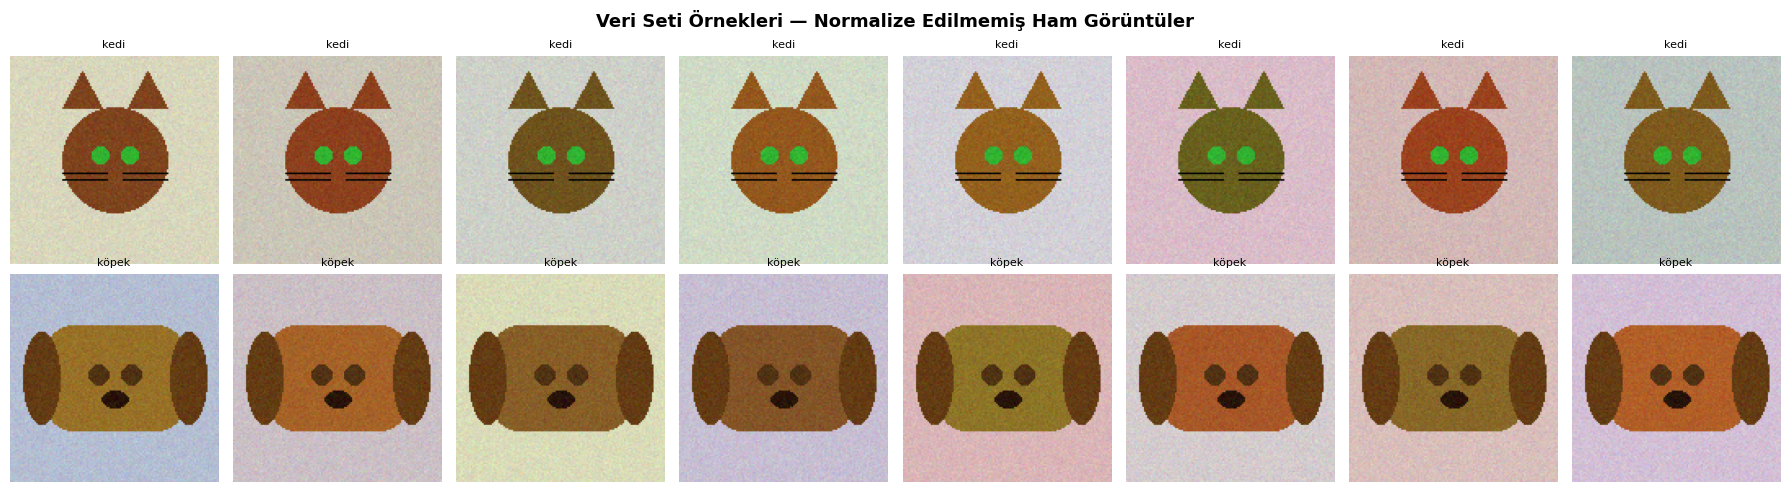

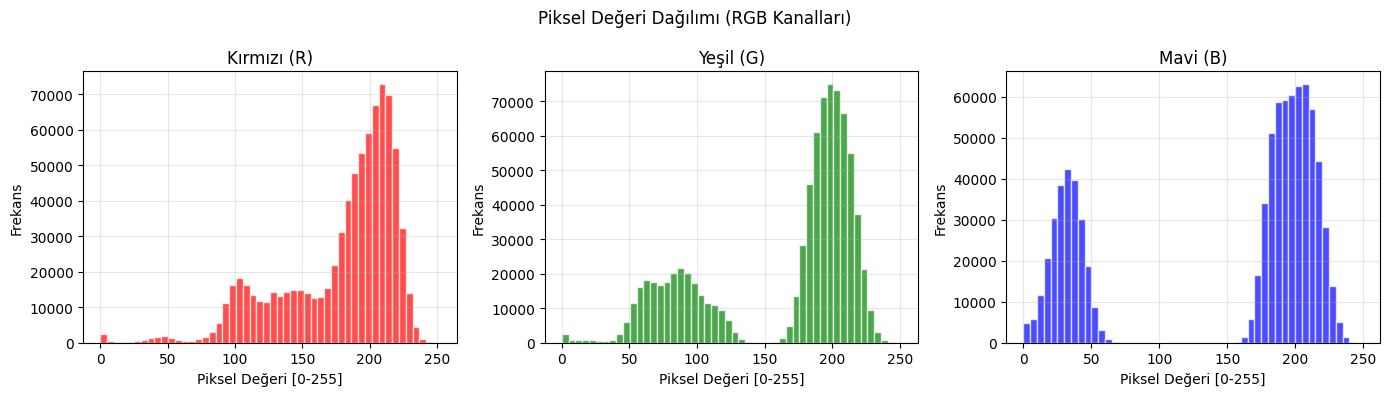

In [5]:
# ── Örnek Görüntüleri Görselleştir ────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Veri Seti Örnekleri — Normalize Edilmemiş Ham Görüntüler',
             fontsize=13, fontweight='bold')

for row, label in enumerate([0, 1]):
    idxs = np.where(y == label)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(X[idx])
        axes[row, col].set_title(CLASSES[label], fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Piksel değeri dağılımını incele
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Piksel Değeri Dağılımı (RGB Kanalları)', fontsize=12)
renkler = ['red', 'green', 'blue']
kanal_isimleri = ['Kırmızı (R)', 'Yeşil (G)', 'Mavi (B)']

for i, (ax, renk, isim) in enumerate(zip(axes, renkler, kanal_isimleri)):
    ax.hist(X[:50, :, :, i].flatten(), bins=50, color=renk, alpha=0.7, edgecolor='white')
    ax.set_title(isim)
    ax.set_xlabel('Piksel Değeri [0-255]')
    ax.set_ylabel('Frekans')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Normalizasyon — Neden Gerekli?

### Problem: Ham Piksel Değerleri [0, 255]

Sinir ağları büyük sayısal aralıklarda kararsız davranır:
- **Gradyan Patlaması:** Büyük değerler türevleri büyütür → ağırlıklar dengesizleşir
- **Yavaş Yakınsama:** Optimize edicinin adımları optimal olmayan boyuta sahip olur
- **Aktivasyon Doygunluğu:** Sigmoid/tanh büyük girdilerde sıfıra yakın gradyan verir

### Çözüm: [0, 1] Aralığına Ölçekle

$$x_{\text{norm}} = \frac{x_{\text{piksel}}}{255.0}$$

Tüm değerler artık **0.0 ile 1.0** arasında → gradyan akışı düzgün → eğitim stabil.

In [6]:
# ── Normalizasyon ──────────────────────────────────────────────
# float32: float64'e göre 2× daha az bellek, GPU'da daha hızlı
X_norm = X.astype(np.float32) / 255.0

print("Normalizasyon öncesi:")
print(f"  dtype  : {X.dtype}")
print(f"  min    : {X.min()}")
print(f"  max    : {X.max()}")
print(f"  mean   : {X.mean():.2f}")

print("\nNormalizasyon sonrası:")
print(f"  dtype  : {X_norm.dtype}")
print(f"  min    : {X_norm.min():.4f}")
print(f"  max    : {X_norm.max():.4f}")
print(f"  mean   : {X_norm.mean():.4f}")

# ── Eğitim / Doğrulama / Test Bölünmesi ──────────────────────
# stratify=y → Her kümedeki kedi/köpek oranı korunur
# Örn: %60 kedi, %40 köpek ise train, val ve test'te de aynı oran

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y,
    test_size    = 0.30,   # %70 eğitim, %30 geri kalan
    random_state = SEED,
    stratify     = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = 0.50,   # Geri kalanın %50'si val, %50'si test
    random_state = SEED,
    stratify     = y_temp
)

print("\nVeri Bölünmesi:")
print(f"  Eğitim    : {len(X_train):5d} görüntü  "
      f"(kedi:{np.sum(y_train==0)}, köpek:{np.sum(y_train==1)})")
print(f"  Doğrulama : {len(X_val):5d} görüntü  "
      f"(kedi:{np.sum(y_val==0)}, köpek:{np.sum(y_val==1)})")
print(f"  Test      : {len(X_test):5d} görüntü  "
      f"(kedi:{np.sum(y_test==0)}, köpek:{np.sum(y_test==1)})")

Normalizasyon öncesi:
  dtype  : uint8
  min    : 0
  max    : 255
  mean   : 161.35

Normalizasyon sonrası:
  dtype  : float32
  min    : 0.0000
  max    : 1.0000
  mean   : 0.6328

Veri Bölünmesi:
  Eğitim    :   700 görüntü  (kedi:350, köpek:350)
  Doğrulama :   150 görüntü  (kedi:75, köpek:75)
  Test      :   150 görüntü  (kedi:75, köpek:75)


---
## 5. Data Augmentation — Veri Artırma

### Overfitting Problemi

Az veriyle eğitilen model eğitim verilerini **ezberler**, yeni görüntülerde başarısız olur.  
Belirtileri:
- Eğitim accuracy: %98 ✅
- Doğrulama accuracy: %62 ❌ → **Overfitting!**

### Çözüm: Mevcut Görüntüleri Dönüştür

Her epoch'ta aynı görüntünün **farklı varyasyonları** üretilir:  
Model aynı görüntüyü iki kez görmez → ezberleme imkansız → genelleme artar

| Augmentation | Açıklama | Gerçek Dünya Karşılığı |
|---|---|---|
| rotation_range=20 | ±20° döndürme | Kameraya eğik tutulan telefon |
| horizontal_flip | Yatay aynalama | Kedi sağa veya sola bakabilir |
| zoom_range=0.15 | %15 yakın/uzak | Farklı mesafeden çekim |
| brightness_range | Parlaklık değişimi | Güneşli/bulutlu gün |
| width/height_shift | Kaydırma | Merkezi olmayan kompozisyon |
| shear_range | Perspektif bozulması | Açılı kamera pozisyonu |

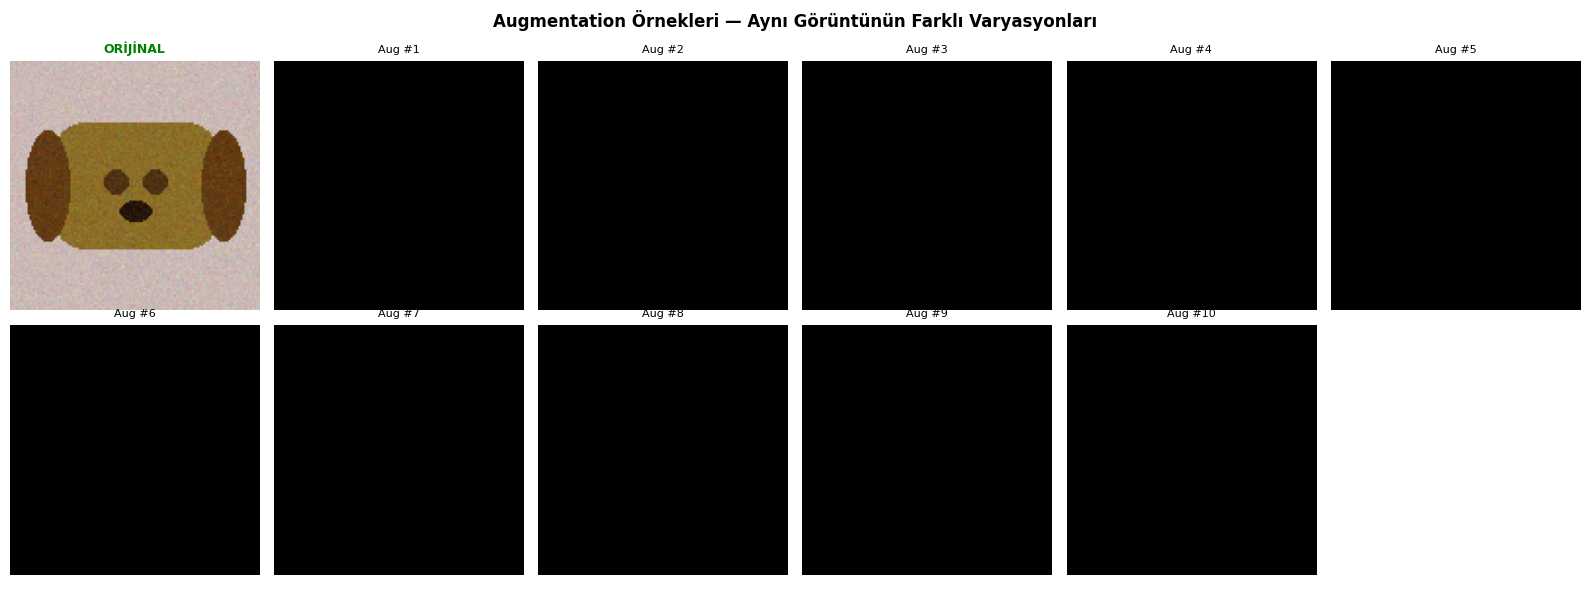


Gözlem: Her görüntü biraz farklı ama içeriği aynı.
Model her epoch'ta farklı varyasyonları gördüğü için ezberleme yapamaz.


In [7]:
# ── ImageDataGenerator ─────────────────────────────────────────
# Gerçek zamanlı (on-the-fly) augmentation yapar.
# Disk'e yazılmaz, bellekte üretilir → hızlı ve verimli.

train_datagen = ImageDataGenerator(
    rotation_range     = 20,      # [-20°, +20°] rastgele döndürme
    width_shift_range  = 0.15,    # Genişliğin %15'i kadar yatay kaydırma
    height_shift_range = 0.15,    # Yüksekliğin %15'i kadar dikey kaydırma
    horizontal_flip    = True,    # %50 ihtimalle yatay çevir
    zoom_range         = 0.15,    # [0.85x, 1.15x] arası zoom
    shear_range        = 0.10,    # Perspektif bozulması (10°'ye kadar)
    brightness_range   = [0.8, 1.2],  # Parlaklık çarpanı
    fill_mode          = 'nearest'    # Kenar pikselleri en yakın değerle doldur
)

# ÖNEMLI: Val ve test için augmentation YAPMA!
# Gerçek dünyada modele gelecek görüntüler artırılmış olmaz.
# Augmentation yaparsan performansı hatalı ölçersin.
val_datagen = ImageDataGenerator()   # Hiçbir dönüşüm yok

# Generator nesneleri — model.fit içinde çağrıldıkça batch üretir
train_gen = train_datagen.flow(
    X_train, y_train,
    batch_size = BATCH_SIZE,
    seed       = SEED
)
val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size = BATCH_SIZE,
    shuffle    = False   # Doğrulamada karıştırma gerekmez
)

# ── Augmentation Sonuçlarını Görselleştir ─────────────────────
sample = X_train[0:1]   # İlk eğitim görüntüsü
aug_gen = train_datagen.flow(sample, batch_size=1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Augmentation Örnekleri — Aynı Görüntünün Farklı Varyasyonları',
             fontsize=12, fontweight='bold')

axes[0, 0].imshow(sample[0])
axes[0, 0].set_title('ORİJİNAL', fontsize=9, color='green', fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(list(axes.flat[1:11])):
    aug_img = next(aug_gen)[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.set_title(f'Aug #{i+1}', fontsize=8)
    ax.axis('off')

axes[1, 5].axis('off')
plt.tight_layout()
plt.show()
print("\nGözlem: Her görüntü biraz farklı ama içeriği aynı.")
print("Model her epoch'ta farklı varyasyonları gördüğü için ezberleme yapamaz.")

---
## 6. Evrişim (Convolution) — Teorik Açıklama

### Evrişim İşlemi Nedir?

Küçük bir **filtre (kernel)** görüntü üzerinde kaydırılır.  
Her konumda filtre ile görüntü bölgesi arasında **nokta çarpımı** hesaplanır.

```
Giriş (5×5):          Filtre (3×3):     Çıkış (3×3):
┌─────────────┐       ┌─────────┐       ┌─────────┐
│ 1  0  2  1  0│       │ 1  0 -1│       │ ?  ?  ? │
│ 0 [3  1  0] 2│  ⊗   │ 1  0 -1│  =   │ ?  ?  ? │
│ 1 [0  2  1] 0│       │ 1  0 -1│       │ ?  ?  ? │
│ 2 [1  0  3] 1│       └─────────┘       └─────────┘
│ 0  1  2  0  1│    (Dikey Kenar Filtresi)
└─────────────┘
```

**Formül:**
$$\text{Çıkış}(i,j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \text{Giriş}(i+m, j+n) \times \text{Filtre}(m,n) + b$$

### Özellik Hiyerarşisi

```
Katman 1 (32 filtre):  Kenarlar, renk geçişleri
                          ↓
Katman 2 (64 filtre):  Köşeler, doku parçaları
                          ↓
Katman 3 (128 filtre): Göz, kulak, burun benzeri yapılar
                          ↓
Katman 4 (256 filtre): Tam kedi/köpek yüzü temsilcileri
```

### Önemli Parametreler

| Parametre | Değer | Anlamı |
|-----------|-------|--------|
| filters | 32, 64, 128, 256 | Kaç farklı özellik öğrenilecek |
| kernel_size | (3,3) | Filtre boyutu — 9 değer bakıyor |
| padding='same' | same | Çıkış boyutu girişle eşit kalır |
| activation='relu' | relu | Negatif değerleri sıfırlar |

### ReLU Aktivasyonu
$$\text{ReLU}(x) = \max(0, x)$$

- Negatif değerleri sıfırlar → seyrek aktivasyon
- Gradyan kaybolması (vanishing gradient) sorununu azaltır
- Hesaplama olarak çok verimli

In [8]:
# ── Evrişimi Elle Hesaplayarak Anla ───────────────────────────
# Küçük bir örnekle evrişim işlemini adım adım gösterelim

import numpy as np

# 5×5 yapay görüntü
goruntu = np.array([
    [1, 0, 2, 1, 0],
    [0, 3, 1, 0, 2],
    [1, 0, 2, 1, 0],
    [2, 1, 0, 3, 1],
    [0, 1, 2, 0, 1]
], dtype=np.float32)

# 3×3 dikey kenar algılama filtresi (Sobel benzeri)
filtre = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=np.float32)

# Elle evrişim — 'valid' padding (kenar ekleme yok)
H, W = goruntu.shape
k    = filtre.shape[0]
cikis = np.zeros((H - k + 1, W - k + 1))

for i in range(H - k + 1):
    for j in range(W - k + 1):
        bolge     = goruntu[i:i+k, j:j+k]   # 3×3 bölge al
        cikis[i,j] = np.sum(bolge * filtre)  # Nokta çarpımı

print("Giriş görüntüsü (5×5):")
print(goruntu.astype(int))
print("\nFiltre (3×3 — Dikey Kenar):")
print(filtre.astype(int))
print("\nEvrişim Çıktısı (3×3):")
print(cikis.astype(int))
print("\nYorum: Pozitif değerler → sola göre sağ taraf daha parlak (dikey kenar)")
print("       Negatif değerler → sola göre sol taraf daha parlak")
print("       Sıfıra yakın    → kenar yok, düzgün bölge")

Giriş görüntüsü (5×5):
[[1 0 2 1 0]
 [0 3 1 0 2]
 [1 0 2 1 0]
 [2 1 0 3 1]
 [0 1 2 0 1]]

Filtre (3×3 — Dikey Kenar):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Evrişim Çıktısı (3×3):
[[-3  1  3]
 [ 0  0  0]
 [-1 -2  2]]

Yorum: Pozitif değerler → sola göre sağ taraf daha parlak (dikey kenar)
       Negatif değerler → sola göre sol taraf daha parlak
       Sıfıra yakın    → kenar yok, düzgün bölge


---
## 7. MaxPooling, BatchNormalization, Dropout — Detaylı Açıklama

### MaxPooling2D

```
Giriş (4×4):         Çıkış (2×2):
┌────────────┐        ┌──────┐
│ 3  1  2  4 │        │ 3  4 │   ← sol üst 2×2'nin maksimumu: 3
│ 1  2  1  2 │  →     │ 5  6 │   ← sağ üst 2×2'nin maksimumu: 4
│ 5  3  6  1 │        └──────┘
│ 2  1  1  2 │
└────────────┘
```

- **Boyut azaltma:** 4×4 → 2×2 (hesaplama maliyeti 4× azalır)
- **Öteleme dayanıklılığı:** Özellik biraz kaymış olsa bile maksimum değer korunur
- **Parametresiz:** Öğrenilecek ağırlık yoktur

### Batch Normalization

Her mini-batch için aktivasyonları normalize eder:

$$\hat{x} = \frac{x - \mu_{\text{batch}}}{\sigma_{\text{batch}} + \epsilon}$$

- **İç kovaryat kayması** problemini çözer
- Daha yüksek öğrenme hızı kullanılabilir → hızlı eğitim
- Hafif düzensizleştirme etkisi
- **Her Conv sonrasına eklenmelidir**

### Dropout

Eğitim sırasında nöronların p olasılıkla sıfırlanması:

```
Dropout(0.25) ile:
  [0.8, 0.3, 0.9, 0.1, 0.7]
           ↓
  [0.8,  0 , 0.9, 0.1,  0 ]   ← 2 nöron sıfırlandı (%25)
```

- Her batch'te **farklı** nöronlar sıfırlanır
- Ağ belirli nöronlara bağımlı hale gelemez → **genelleme artar**
- **Test sırasında Dropout kapalıdır** (model.predict otomatik yapar)

In [9]:
# ── Evrişimi Elle Hesaplayarak Anla ───────────────────────────
# Küçük bir örnekle evrişim işlemini adım adım gösterelim

import numpy as np

# 5×5 yapay görüntü
goruntu = np.array([
    [1, 0, 2, 1, 0],
    [0, 3, 1, 0, 2],
    [1, 0, 2, 1, 0],
    [2, 1, 0, 3, 1],
    [0, 1, 2, 0, 1]
], dtype=np.float32)

# 3×3 dikey kenar algılama filtresi (Sobel benzeri)
filtre = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=np.float32)

# Elle evrişim — 'valid' padding (kenar ekleme yok)
H, W = goruntu.shape
k    = filtre.shape[0]
cikis = np.zeros((H - k + 1, W - k + 1))

for i in range(H - k + 1):
    for j in range(W - k + 1):
        bolge     = goruntu[i:i+k, j:j+k]   # 3×3 bölge al
        cikis[i,j] = np.sum(bolge * filtre)  # Nokta çarpımı

print("Giriş görüntüsü (5×5):")
print(goruntu.astype(int))
print("\nFiltre (3×3 — Dikey Kenar):")
print(filtre.astype(int))
print("\nEvrişim Çıktısı (3×3):")
print(cikis.astype(int))
print("\nYorum: Pozitif değerler → sola göre sağ taraf daha parlak (dikey kenar)")
print("       Negatif değerler → sola göre sol taraf daha parlak")
print("       Sıfıra yakın    → kenar yok, düzgün bölge")

Giriş görüntüsü (5×5):
[[1 0 2 1 0]
 [0 3 1 0 2]
 [1 0 2 1 0]
 [2 1 0 3 1]
 [0 1 2 0 1]]

Filtre (3×3 — Dikey Kenar):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Evrişim Çıktısı (3×3):
[[-3  1  3]
 [ 0  0  0]
 [-1 -2  2]]

Yorum: Pozitif değerler → sola göre sağ taraf daha parlak (dikey kenar)
       Negatif değerler → sola göre sol taraf daha parlak
       Sıfıra yakın    → kenar yok, düzgün bölge


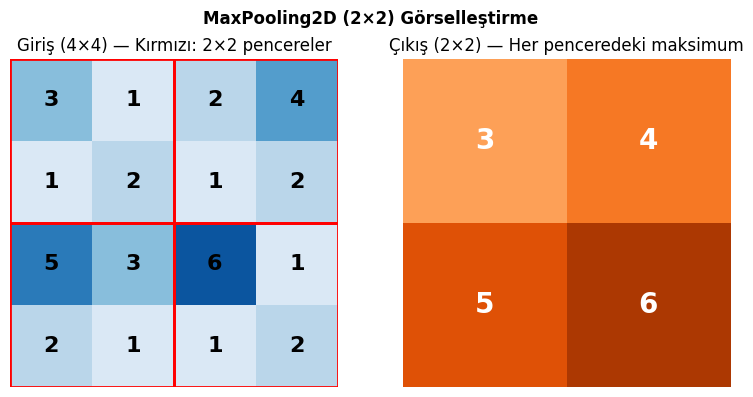

In [10]:
# ── MaxPooling'i Görselleştir ──────────────────────────────────
ornek = np.array([[3, 1, 2, 4],
                  [1, 2, 1, 2],
                  [5, 3, 6, 1],
                  [2, 1, 1, 2]], dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('MaxPooling2D (2×2) Görselleştirme', fontsize=12, fontweight='bold')

# Giriş
axes[0].imshow(ornek, cmap='Blues', vmin=0, vmax=7)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(int(ornek[i,j])),
                     ha='center', va='center', fontsize=16, fontweight='bold')
# 2×2 pencere ızgaraları
for i in [0, 2]:
    for j in [0, 2]:
        rect = plt.Rectangle((j-0.5, i-0.5), 2, 2,
                              fill=False, edgecolor='red', linewidth=2)
        axes[0].add_patch(rect)
axes[0].set_title('Giriş (4×4) — Kırmızı: 2×2 pencereler')
axes[0].axis('off')

# Çıkış (maksimumlar)
cikis_pool = np.array([[3, 4], [5, 6]], dtype=np.float32)
axes[1].imshow(cikis_pool, cmap='Oranges', vmin=0, vmax=7)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(int(cikis_pool[i,j])),
                     ha='center', va='center', fontsize=20, fontweight='bold', color='white')
axes[1].set_title('Çıkış (2×2) — Her penceredeki maksimum')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 8. CNN Mimarisi — Katman Katman Detaylı Analiz

In [11]:
def build_cnn(input_shape=(128, 128, 3)):
    """
    4 evrişimsel blok + sınıflandırıcı başı.

    Boyut değişim özeti:
    Giriş:   128×128×3
    Blok 1:  128×128×32  → Pool → 64×64×32
    Blok 2:   64×64×64   → Pool → 32×32×64
    Blok 3:   32×32×128  → Pool → 16×16×128
    Blok 4:   16×16×256  → Pool →  8×8×256
    GAP:     256 (vektör)
    Dense:   64
    Çıkış:   1 (sigmoid)
    """
    model = models.Sequential(name='KediKopek_CNN')

    # ── GİRİŞ ────────────────────────────────────────────────
    model.add(layers.Input(shape=input_shape))
    # input_shape=(128, 128, 3):
    #   128 → yükseklik (piksel)
    #   128 → genişlik (piksel)
    #   3   → RGB kanalı (R, G, B)

    # ── BLOK 1: İlkel Özellikler ──────────────────────────────
    # Bu katmanda ağ: dikey kenarlar, yatay kenarlar,
    # renk geçişleri gibi düşük seviyeli özellikleri öğrenir

    model.add(layers.Conv2D(
        filters    = 32,        # 32 farklı filtre → 32 özellik haritası
        kernel_size= (3, 3),    # 3×3 piksel penceresi
        padding    = 'same',    # Kenar ekleme → çıkış boyutu = giriş boyutu
        activation = 'relu'     # ReLU: max(0,x) — negatif sıfırla
    ))  # Çıkış: 128×128×32

    model.add(layers.BatchNormalization())
    # Aktivasyonları normalize et → eğitim stabil, hızlı

    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    # İkinci Conv aynı boyutu korur ama daha karmaşık özellikler öğrenir

    model.add(layers.MaxPooling2D((2, 2)))
    # 128×128 → 64×64 (boyut yarıya iner)

    model.add(layers.Dropout(0.25))
    # Eğitimde nöronların %25'ini rastgele kapat → overfitting önle

    # ── BLOK 2: Orta Seviye Özellikler ───────────────────────
    # Özellik sayısı 32 → 64: daha zengin temsil kapasitesi
    # Boyut 64×64 → 32×32

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 64×64 → 32×32
    model.add(layers.Dropout(0.25))

    # ── BLOK 3: Yüksek Seviye Özellikler ─────────────────────
    # 64 → 128 filtre: kedi kulağı, köpek burnu gibi yapılar
    # Boyut 32×32 → 16×16

    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 32×32 → 16×16
    model.add(layers.Dropout(0.25))

    # ── BLOK 4: Soyut Özellikler ──────────────────────────────
    # 128 → 256 filtre: çok karmaşık örüntüler
    # Boyut 16×16 → 8×8

    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 16×16 → 8×8
    model.add(layers.Dropout(0.25))

    # ── SINIFLANDIRICI BAŞ ────────────────────────────────────

    model.add(layers.GlobalAveragePooling2D())
    # 8×8×256 → 256 boyutlu vektör
    # Flatten yerine GAP tercih sebebi:
    #   Flatten: 8×8×256 = 16384 parametre (çok büyük)
    #   GAP: Her kanalın ortalaması = 256 (çok küçük)
    # → Parametre azaltır, overfitting düşürür

    model.add(layers.Dense(256, activation='relu'))
    # Tam bağlantılı katman: tüm özellikler bir araya gelir

    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))  # Dense katmanlarda daha güçlü dropout

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.30))

    model.add(layers.Dense(1, activation='sigmoid'))
    # Çıkış: 0.0-1.0 arası tek değer
    # sigmoid(x) = 1 / (1 + e^(-x))
    # < 0.5 → kedi, ≥ 0.5 → köpek

    return model


cnn_model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3))
cnn_model.summary()

# Toplam parametre sayısını yorumla
total = cnn_model.count_params()
print(f"\nToplam Parametre: {total:,}")
print(f"Bellek (float32): ~{total * 4 / 1024**2:.1f} MB")

Model: "KediKopek_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,321 (2.55 MB)

 Trainable params: 666,401 (2.54 MB)

 Non-trainable params: 1,920 (7.50 KB)


Toplam Parametre: 668,321
Bellek (float32): ~2.5 MB


---
## 9. Transfer Learning — VGG16 ile İnce Ayar

### Neden Transfer Learning?

VGG16, 1.2 milyon görüntü üzerinde eğitilmiş ve genel görsel özellikler öğrenmiştir:
- Kenarlar, köşeler, renkler → evrensel, her görüntüde var
- Dokular, şekiller → çoğu görüntüde var
- Bu özellikler kedi-köpek için de geçerlidir!

### İki Aşamalı Strateji

```
Aşama 1 — Dondur ve Eğit:
  VGG16 (dondurulmuş) → bizim sınıflandırıcı (eğitilir)
  LR: 1e-3  — hızlı yakınsama

Aşama 2 — Fine-Tuning:
  VGG16 son 4 katman (açılır) + sınıflandırıcı
  LR: 1e-5  — çok yavaş güncelleme (eskiyi bozmamak için)
```

In [12]:
def build_transfer_model(input_shape=(128, 128, 3)):
    """
    VGG16 tabanlı transfer learning modeli.
    İki aşamalı eğitim için tasarlanmıştır.
    """
    # ── Temel Model ────────────────────────────────────────────
    base = VGG16(
        weights     = 'imagenet',  # ImageNet ağırlıklarını indir
        include_top = False,       # Son 3 Dense katmanı dahil etme
        input_shape = input_shape
    )
    print(f"VGG16 katman sayısı: {len(base.layers)}")
    print("\nVGG16 Mimarisi:")

    for i, layer in enumerate(base.layers):
        try:
            shape = layer.output.shape
        except AttributeError:
            shape = "N/A"
        print(f"  [{i:2d}] {layer.name:25s} → çıkış: {shape}")

    # Tüm katmanları dondur — ağırlıklar değişmeyecek
    base.trainable = False
    print(f"\nEğitilebilir ağırlık: {sum(tf.size(w).numpy() for w in base.trainable_weights):,}")

    # ── Özel Sınıflandırıcı Baş ────────────────────────────────
    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)   # training=False → BN dondurulmuş modda
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.50)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='Transfer_VGG16')
    return model, base

---
## 10. Kayıp Fonksiyonu ve Optimizer

### Binary Cross-Entropy — Kayıp Fonksiyonu

İkili sınıflandırma için standart kayıp fonksiyonu:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]$$

Örnekler:
- Gerçek: köpek (y=1), Tahmin: 0.9 → Kayıp: -log(0.9) ≈ 0.10 ✅ (düşük)
- Gerçek: köpek (y=1), Tahmin: 0.1 → Kayıp: -log(0.1) ≈ 2.30 ❌ (yüksek)
- Gerçek: kedi  (y=0), Tahmin: 0.8 → Kayıp: -log(0.2) ≈ 1.61 ❌ (yüksek)

### Adam Optimizer

Adaptive Moment Estimation — her parametre için ayrı öğrenme hızı tutar:
- **m:** 1. moment (gradyan ortalaması) — momentum yönünü belirler
- **v:** 2. moment (kare gradyan ortalaması) — adım boyutunu ölçekler

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

Neden Adam?
- SGD'ye göre çok daha hızlı yakınsama
- Öğrenme hızını elle ayarlamak yerine otomatik uyarlar
- Varsayılan lr=1e-3 çoğu problemde iyi çalışır

In [13]:
cnn_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

# tl_model daha önce oluşturulmadıysa burada oluştur
tl_model, base_model = build_transfer_model((IMG_SIZE, IMG_SIZE, 3))

tl_model.compile(
    optimizer = optimizers.Adam(1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 katman sayısı: 19

VGG16 Mimarisi:
  [ 0] input_layer_1             → çıkış: (None, 128, 128, 3)
  [ 1] block1_conv1              → çıkış: (None, 128, 128, 64)
  [ 2] block1_conv2              → çıkış: (None, 128, 128, 64)
  [ 3] block1_pool               → çıkış: (None, 64, 64, 64)
  [ 4] block2_conv1              → çıkış: (None, 64, 64, 128)
  [ 5] block2_conv2              → çıkış: (None, 64, 64, 128)
  [ 6] block2_pool               → çıkış: (None, 32, 32, 128)
  [ 7] block3_conv1              → çıkış: (None, 32, 32, 256)
  [ 8] block3_conv2              → çıkış: (None, 32, 32, 256)
  [ 9] block3_conv3              → çıkış: (None, 32, 32, 256)
  [10] block3_pool               → çıkış: (None, 16, 16, 256)
  [11] block4_conv1              → çıkış: (None, 16, 16, 512)
  [12] block4_conv2              → çıkış: (None, 16, 16, 512)
  [13] block4_conv3              → çıkış: (None, 16, 16, 512)
  [14] block4_pool               → çıkı

---
## 11. Callback'ler — Akıllı Eğitim Kontrolü

Her epoch sonunda çağrılan fonksiyonlardır.

| Callback | Ne Zaman Tetiklenir | Ne Yapar |
|---|---|---|
| EarlyStopping | val_accuracy durma platosunda | Eğitimi durdurur, en iyi ağırlıkları geri yükler |
| ReduceLROnPlateau | val_loss iyileşmiyorsa | Öğrenme hızını yarıya indirir |
| ModelCheckpoint | Her epoch | En iyi modeli diske kaydeder |

In [14]:
# ── CNN Callback'leri ──────────────────────────────────────────
cnn_callbacks = [

    callbacks.EarlyStopping(
        monitor             = 'val_accuracy',
        # Doğrulama accuracy'sini izle
        # 'val_loss' da kullanılabilir

        patience            = 8,
        # 8 epoch boyunca iyileşme olmazsa dur
        # Çok küçük: erken durur (underfitting riski)
        # Çok büyük: fazla bekler (overfitting riski)

        restore_best_weights= True,
        # Durduğunda en iyi epoch'taki ağırlıklara dön
        # False ise son epoch'taki ağırlıklar kalır

        verbose             = 1
    ),

    callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,       # Yeni LR = Eski LR × 0.5
        patience = 4,         # 4 epoch bekleme
        min_lr   = 1e-6,      # LR bu değerden küçük olamaz
        verbose  = 1
    ),

    callbacks.ModelCheckpoint(
        filepath       = 'best_cnn_model.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,   # Sadece iyileşme olursa kaydet
        verbose        = 0
    )
]

print("Callback'ler hazır:")
print("  ✓ EarlyStopping  — patience=8, best weights restored")
print("  ✓ ReduceLROnPlateau — factor=0.5, patience=4")
print("  ✓ ModelCheckpoint — best_cnn_model.keras")

Callback'ler hazır:
  ✓ EarlyStopping  — patience=8, best weights restored
  ✓ ReduceLROnPlateau — factor=0.5, patience=4
  ✓ ModelCheckpoint — best_cnn_model.keras


---
## 12. Eğitim Döngüsü

### model.fit() İçinde Ne Olur?

```
Her Epoch:
  ├── Eğitim Adımı:
  │     ├── Batch al (augmentation uygulanmış)
  │     ├── İleri yayılım (forward pass): tahmin üret
  │     ├── Kayıp hesapla (binary_crossentropy)
  │     ├── Geri yayılım (backward pass): gradyanları hesapla
  │     └── Ağırlıkları güncelle (Adam adımı)
  │
  └── Doğrulama Adımı:
        ├── Val batch'lerini al (augmentation YOK)
        ├── İleri yayılım (tahmin üret)
        ├── Kayıp ve metrikleri hesapla
        └── Callback'leri tetikle (EarlyStopping vb.)
```

In [15]:
# ── CNN Eğitimi ────────────────────────────────────────────────
print("=" * 60)
print("  CNN from Scratch — Eğitim Başlıyor")
print("=" * 60)

cnn_history = cnn_model.fit(
    train_gen,           # Augmentation uygulanmış eğitim batch'leri
    epochs          = EPOCHS,
    validation_data = val_gen,   # Doğrulama verisi (augmentation yok)
    callbacks       = cnn_callbacks,
    verbose         = 1          # Her epoch'u yazdır
)

print("\nCNN eğitimi tamamlandı!")
best_val_acc = max(cnn_history.history['val_accuracy'])
print(f"En iyi doğrulama accuracy: {best_val_acc:.4f}")

  CNN from Scratch — Eğitim Başlıyor
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4829 - loss: 0.6932 - precision: 0.4910 - recall: 0.9371 - val_accuracy: 0.4467 - val_loss: 0.6932 - val_precision: 0.3947 - val_recall: 0.2000 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5000 - recall: 1.0000 - val_accuracy: 0.4667 - val_loss: 0.6932 - val_precision: 0.3529 - val_recall: 0.0800 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5000 - recall: 1.0000 - val_accuracy: 0.4600 - val_loss: 0.6934 - val_precision: 0.2000 - val_recall: 0.0267 - learning_rate: 0.0010
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5000 - recall: 1.0000 - val_accuracy: 0.4800 - val_loss: 0.6938 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/20
22/22 ━━━━

In [16]:
# ── Transfer Learning Eğitimi ──────────────────────────────────
tl_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=3, verbose=1)
]

print("=" * 60)
print("  Transfer Learning — Aşama 1: Baş Katmanları Eğit")
print("=" * 60)

tl_hist1 = tl_model.fit(
    train_gen,
    epochs          = max(5, EPOCHS // 4),
    validation_data = val_gen,
    callbacks       = tl_callbacks,
    verbose         = 1
)

# ── Fine-Tuning ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  Aşama 2: Fine-Tuning (VGG16 son 4 katman açılıyor)")
print("=" * 60)

base_model.trainable = True
# Tüm katmanları önce dondur, sonra seçici aç
for layer in base_model.layers[:-4]:
    layer.trainable = False

acik = sum(1 for l in base_model.layers if l.trainable)
print(f"VGG16'da açık katman sayısı: {acik} / {len(base_model.layers)}")

# Fine-tuning için çok daha düşük LR kullan!
# Yüksek LR önceki öğrenilenler ezer (catastrophic forgetting)
tl_model.compile(
    optimizer = optimizers.Adam(1e-5),   # 1e-3'ün 100'de biri
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

tl_hist2 = tl_model.fit(
    train_gen,
    epochs          = max(5, EPOCHS // 4),
    validation_data = val_gen,
    callbacks       = tl_callbacks,
    verbose         = 1
)

print("\nTransfer Learning eğitimi tamamlandı!")

  Transfer Learning — Aşama 1: Baş Katmanları Eğit
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 739ms/step - accuracy: 0.4800 - loss: 0.6933 - precision: 0.4878 - recall: 0.7971 - val_accuracy: 0.5000 - val_loss: 0.7277 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.5086 - loss: 0.6934 - precision: 0.5375 - recall: 0.1229 - val_accuracy: 0.5000 - val_loss: 0.7402 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.4729 - loss: 0.6934 - precision: 0.4718 - recall: 0.4543 - val_accuracy: 0.5000 - val_loss: 0.7553 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.4929 - loss: 0.6932 - precision: 0.5035 - recall: 0.8324
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
22/22 ━━━━━━━━━━━━━━━━━━━━ 

---
## 13. Değerlendirme Metrikleri — Detaylı Açıklama

### Confusion Matrix (Karışıklık Matrisi)

```
                  TAHMİN
              Kedi    Köpek
GERÇEK  Kedi  [TN]    [FP]   ← kedi ama köpek dendi
       Köpek  [FN]    [TP]   ← köpek ama kedi dendi
```

| Metrik | Formül | Ne Zaman Önemli? |
|--------|--------|------------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Dengeli veri setinde |
| **Precision** | TP/(TP+FP) | "Pozitif" sonuçların güvenilirliği |
| **Recall** | TP/(TP+FN) | Pozitif örneklerin yakalanma oranı |
| **F1 Score** | 2×P×R/(P+R) | Precision ve Recall dengesi |
| **ROC-AUC** | Eğri altındaki alan | Eşikten bağımsız genel performans |

### Precision vs Recall Trade-off
- Köpek alerjisi olan hastane → Precision kritik (köpek dediğinde kesinlikle köpek olsun)
- Köpek kaçırma uyarı sistemi → Recall kritik (hiçbir köpeği kaçırma)

---
## 13. Değerlendirme Metrikleri — Detaylı Açıklama

### Confusion Matrix (Karışıklık Matrisi)

```
                  TAHMİN
              Kedi    Köpek
GERÇEK  Kedi  [TN]    [FP]   ← kedi ama köpek dendi
       Köpek  [FN]    [TP]   ← köpek ama kedi dendi
```

| Metrik | Formül | Ne Zaman Önemli? |
|--------|--------|------------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Dengeli veri setinde |
| **Precision** | TP/(TP+FP) | "Pozitif" sonuçların güvenilirliği |
| **Recall** | TP/(TP+FN) | Pozitif örneklerin yakalanma oranı |
| **F1 Score** | 2×P×R/(P+R) | Precision ve Recall dengesi |
| **ROC-AUC** | Eğri altındaki alan | Eşikten bağımsız genel performans |

### Precision vs Recall Trade-off
- Köpek alerjisi olan hastane → Precision kritik (köpek dediğinde kesinlikle köpek olsun)
- Köpek kaçırma uyarı sistemi → Recall kritik (hiçbir köpeği kaçırma)


  CNN from Scratch — Test Seti Değerlendirmesi
  Accuracy  : 0.4933  (49.3% doğru tahmin)
  F1 Score  : 0.0000
  ROC-AUC   : 0.3973  (1.0=mükemmel, 0.5=rastgele)

  Sınıflandırma Raporu:
              precision    recall  f1-score   support

        kedi     0.4966    0.9867    0.6607        75
       köpek     0.0000    0.0000    0.0000        75

    accuracy                         0.4933       150
   macro avg     0.2483    0.4933    0.3304       150
weighted avg     0.2483    0.4933    0.3304       150

  Confusion Matrix:
    TN (doğru kedi)    :   74
    FP (yanlış köpek)  :    1  ← kedileri köpek sandık
    FN (yanlış kedi)   :   75  ← köpekleri kedi sandık
    TP (doğru köpek)   :    0


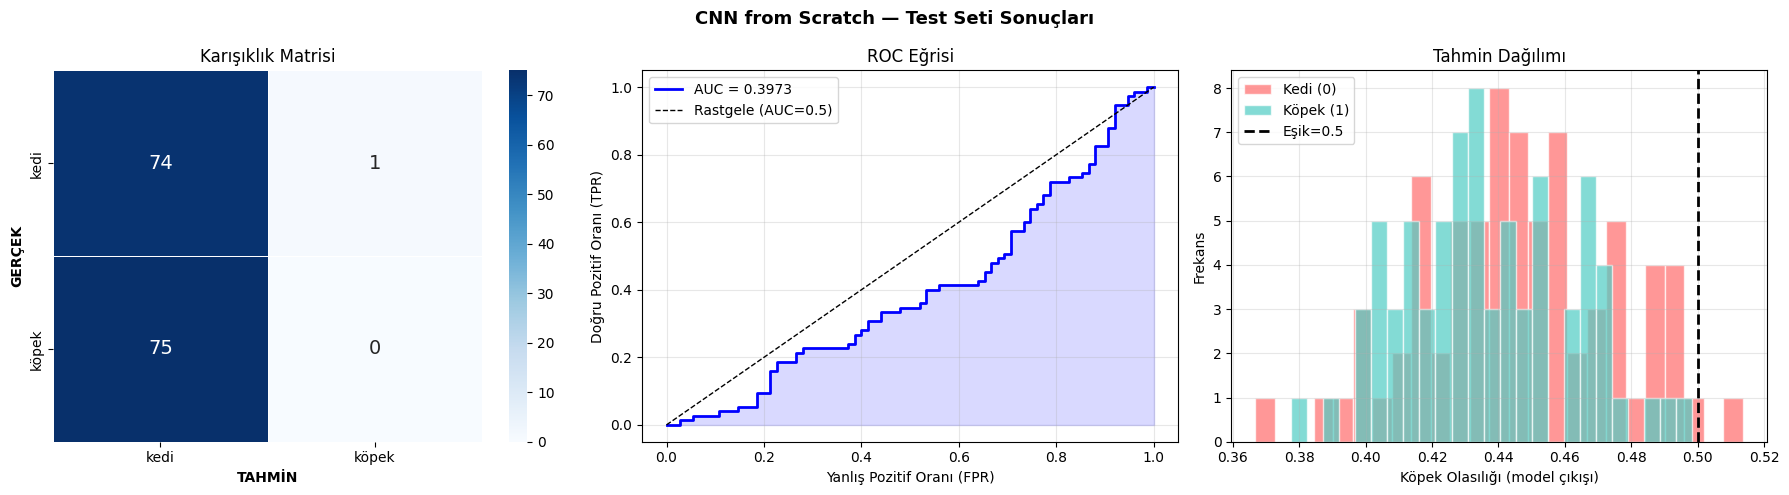


  Transfer VGG16 — Test Seti Değerlendirmesi
  Accuracy  : 0.5000  (50.0% doğru tahmin)
  F1 Score  : 0.0000
  ROC-AUC   : 0.3689  (1.0=mükemmel, 0.5=rastgele)

  Sınıflandırma Raporu:
              precision    recall  f1-score   support

        kedi     0.5000    1.0000    0.6667        75
       köpek     0.0000    0.0000    0.0000        75

    accuracy                         0.5000       150
   macro avg     0.2500    0.5000    0.3333       150
weighted avg     0.2500    0.5000    0.3333       150

  Confusion Matrix:
    TN (doğru kedi)    :   75
    FP (yanlış köpek)  :    0  ← kedileri köpek sandık
    FN (yanlış kedi)   :   75  ← köpekleri kedi sandık
    TP (doğru köpek)   :    0


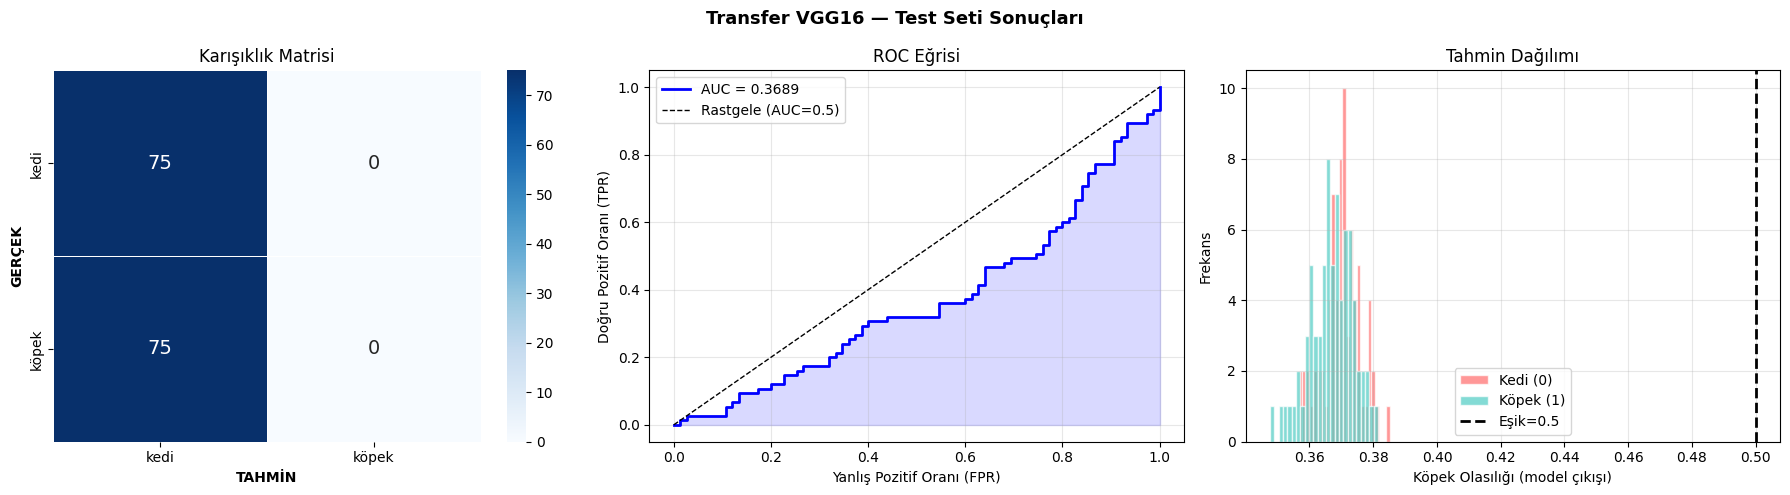

In [17]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Kapsamlı model değerlendirmesi."""
    print(f"\n{'='*60}")
    print(f"  {model_name} — Test Seti Değerlendirmesi")
    print(f"{'='*60}")

    # Olasılık ve etiket tahmini
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    # Temel metrikler
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}% doğru tahmin)")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}  (1.0=mükemmel, 0.5=rastgele)")

    # Detaylı sınıflandırma raporu
    print(f"\n  Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

    # Görselleştirme
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Test Seti Sonuçları', fontsize=13, fontweight='bold')

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=axes[0], annot_kws={'size': 14})
    axes[0].set_xlabel('TAHMİN', fontweight='bold')
    axes[0].set_ylabel('GERÇEK', fontweight='bold')
    axes[0].set_title('Karışıklık Matrisi')

    # Yüzdeli yorumlama
    tn, fp, fn, tp = cm.ravel()
    print(f"  Confusion Matrix:")
    print(f"    TN (doğru kedi)    : {tn:4d}")
    print(f"    FP (yanlış köpek)  : {fp:4d}  ← kedileri köpek sandık")
    print(f"    FN (yanlış kedi)   : {fn:4d}  ← köpekleri kedi sandık")
    print(f"    TP (doğru köpek)   : {tp:4d}")

    # 2. ROC Eğrisi
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele (AUC=0.5)')
    axes[1].fill_between(fpr, tpr, alpha=0.15, color='blue')
    axes[1].set_xlabel('Yanlış Pozitif Oranı (FPR)')
    axes[1].set_ylabel('Doğru Pozitif Oranı (TPR)')
    axes[1].set_title('ROC Eğrisi')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. Tahmin Olasılığı Dağılımı
    axes[2].hist(y_prob[y_test==0], bins=25, alpha=0.7,
                 color='#FF6B6B', label='Kedi (0)', edgecolor='white')
    axes[2].hist(y_prob[y_test==1], bins=25, alpha=0.7,
                 color='#4ECDC4', label='Köpek (1)', edgecolor='white')
    axes[2].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Eşik=0.5')
    axes[2].set_xlabel('Köpek Olasılığı (model çıkışı)')
    axes[2].set_ylabel('Frekans')
    axes[2].set_title('Tahmin Dağılımı')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    # İyi model: kedi olasılıkları 0'a, köpek olasılıkları 1'e toplanmalı

    plt.tight_layout()
    plt.show()
    return y_prob, y_pred


# ── Her İki Modeli Değerlendir ─────────────────────────────────
cnn_prob, cnn_pred = evaluate_model(cnn_model, X_test, y_test, 'CNN from Scratch')
tl_prob,  tl_pred  = evaluate_model(tl_model,  X_test, y_test, 'Transfer VGG16')

---
## 14. Eğitim Geçmişi Görselleştirme

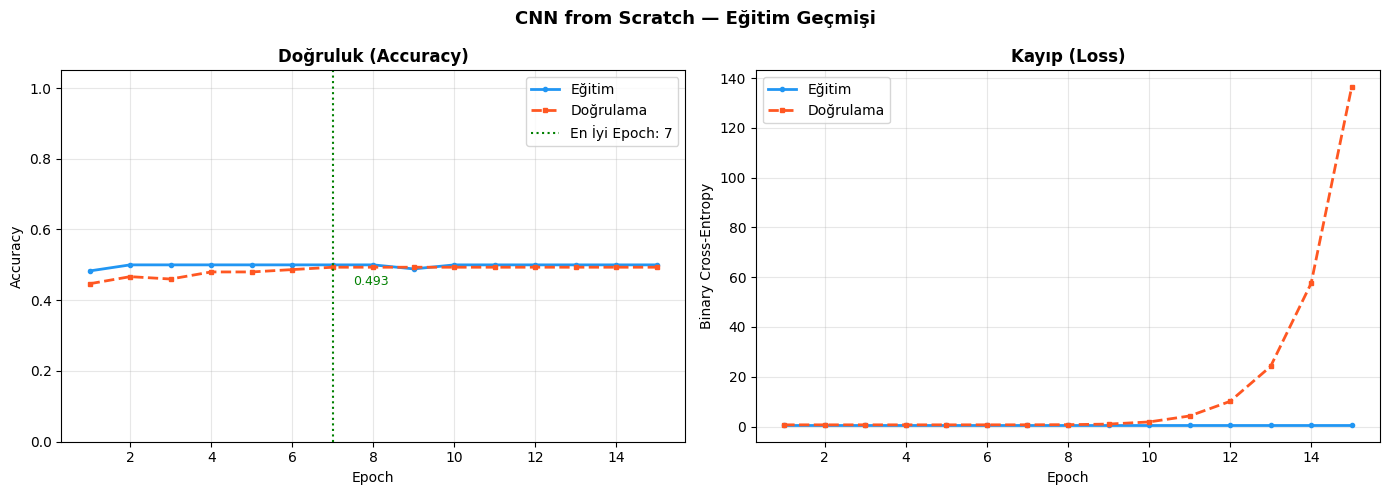


Son epoch — Eğitim: 0.5000 | Doğrulama: 0.4933
Fark (overfitting göstergesi): 0.0067
✅  Çok iyi genelleme!


In [18]:
def plot_history(history, title):
    """
    Accuracy ve Loss grafiklerini yan yana çizer.
    Eğitim ve doğrulama eğrilerinin açıklaması:
    - İki eğri birbirine yakın → iyi genelleme
    - Eğitim yüksek, doğrulama düşük → overfitting
    - İkisi de düşük → underfitting (model yeterince öğrenemiyor)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # ── Accuracy ──────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs_range, history.history['accuracy'],
            color='#2196F3', linewidth=2, label='Eğitim', marker='o', markersize=3)
    ax.plot(epochs_range, history.history['val_accuracy'],
            color='#FF5722', linewidth=2, label='Doğrulama',
            marker='s', markersize=3, linestyle='--')
    # En iyi doğrulama epoch'unu işaretle
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_val   = max(history.history['val_accuracy'])
    ax.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
               label=f'En İyi Epoch: {best_epoch}')
    ax.annotate(f'{best_val:.3f}',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 0.5, best_val - 0.05),
                fontsize=9, color='green')
    ax.set_title('Doğruluk (Accuracy)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1.05])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Loss ──────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs_range, history.history['loss'],
            color='#2196F3', linewidth=2, label='Eğitim', marker='o', markersize=3)
    ax.plot(epochs_range, history.history['val_loss'],
            color='#FF5722', linewidth=2, label='Doğrulama',
            marker='s', markersize=3, linestyle='--')
    ax.set_title('Kayıp (Loss)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Cross-Entropy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Overfitting analizi
    son_train = history.history['accuracy'][-1]
    son_val   = history.history['val_accuracy'][-1]
    fark      = son_train - son_val
    print(f"\nSon epoch — Eğitim: {son_train:.4f} | Doğrulama: {son_val:.4f}")
    print(f"Fark (overfitting göstergesi): {fark:.4f}")
    if fark > 0.10:
        print("⚠️  Overfitting var! Dropout artır veya daha fazla veri topla.")
    elif fark < 0.02:
        print("✅  Çok iyi genelleme!")
    else:
        print("🟡  Hafif overfitting — kabul edilebilir aralıkta.")


plot_history(cnn_history, 'CNN from Scratch — Eğitim Geçmişi')

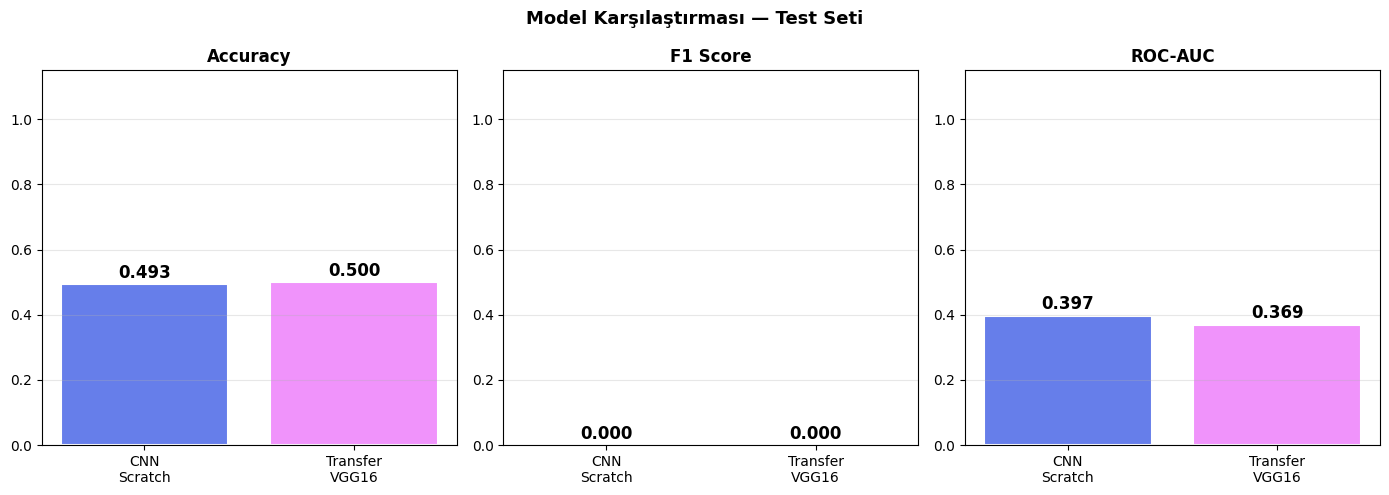


Karşılaştırma Tablosu:
Model                  Accuracy         F1    ROC-AUC
-------------------------------------------------------
CNN Scratch              0.4933     0.0000     0.3973
Transfer VGG16           0.5000     0.0000     0.3689


In [19]:
# ── Model Karşılaştırma Grafiği ────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model_isimleri = ['CNN\nScratch', 'Transfer\nVGG16']
acclari = [accuracy_score(y_test, cnn_pred), accuracy_score(y_test, tl_pred)]
f1lari  = [f1_score(y_test, cnn_pred),       f1_score(y_test, tl_pred)]
auclari = [roc_auc_score(y_test, cnn_prob),  roc_auc_score(y_test, tl_prob)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Karşılaştırması — Test Seti', fontsize=13, fontweight='bold')

renkler = ['#667eea', '#f093fb']
for ax, degerler, baslik in zip(
        axes, [acclari, f1lari, auclari],
        ['Accuracy', 'F1 Score', 'ROC-AUC']):
    bars = ax.bar(model_isimleri, degerler, color=renkler, edgecolor='white', linewidth=1.5)
    ax.set_title(baslik, fontweight='bold')
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3)
    for bar, deger in zip(bars, degerler):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{deger:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKarşılaştırma Tablosu:")
print(f"{'Model':20s} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 55)
print(f"{'CNN Scratch':20s} {acclari[0]:>10.4f} {f1lari[0]:>10.4f} {auclari[0]:>10.4f}")
print(f"{'Transfer VGG16':20s} {acclari[1]:>10.4f} {f1lari[1]:>10.4f} {auclari[1]:>10.4f}")

---
## 15. Tek Görüntü Üzerinde Tahmin

### Dikkat Edilmesi Gereken Adımlar

Modele yeni görüntü verirken eğitim sürecindeki **tüm ön işlemleri** tekrar uygulamak zorundasın:

1. BGR → RGB (eğitimde de yapıldı)
2. 128×128 resize (eğitimde de yapıldı)
3. /255.0 normalizasyon (eğitimde de yapıldı)
4. `[np.newaxis, ...]` ile batch boyutu ekle (model toplu giriş bekler)

Test setinden rastgele örnekler:

Gerçek Etiket: KEDI


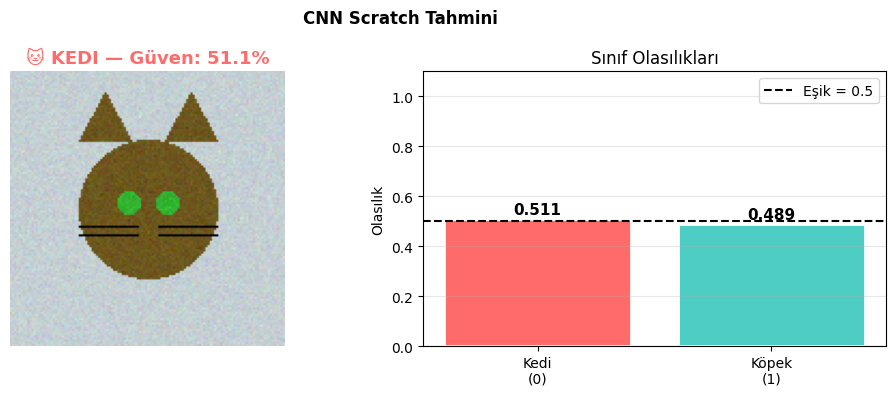

Tahmin   : KEDI 🐱
Güven    : 51.06%
P(köpek) : 0.4894
P(kedi)  : 0.5106
----------------------------------------
Gerçek Etiket: KEDI


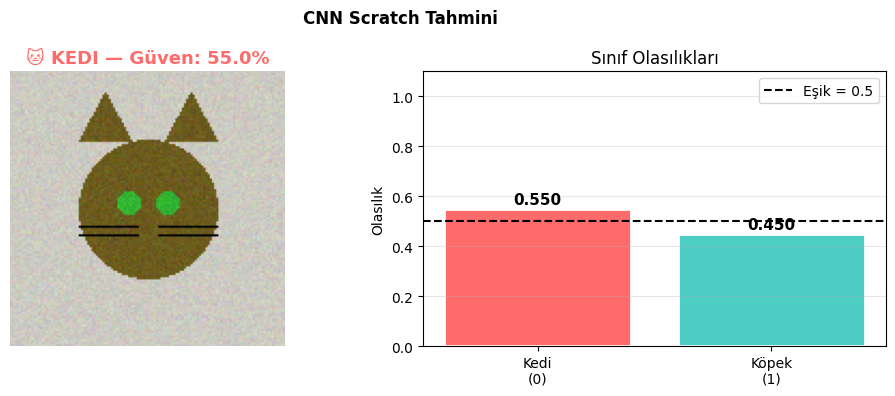

Tahmin   : KEDI 🐱
Güven    : 55.04%
P(köpek) : 0.4496
P(kedi)  : 0.5504
----------------------------------------
Gerçek Etiket: KEDI


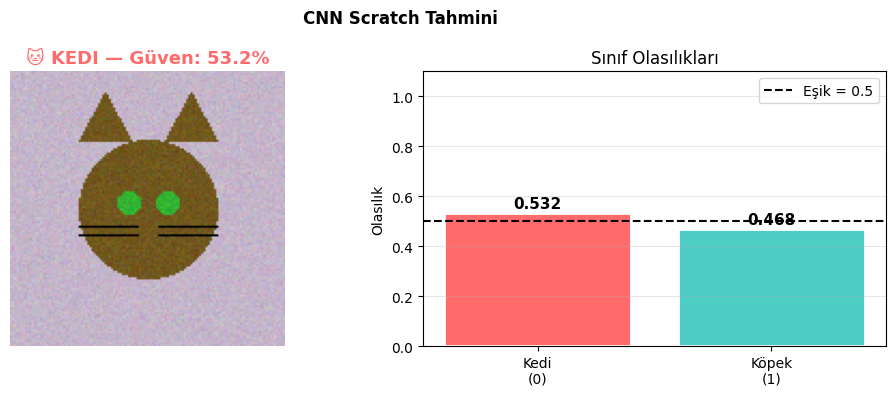

Tahmin   : KEDI 🐱
Güven    : 53.25%
P(köpek) : 0.4675
P(kedi)  : 0.5325
----------------------------------------


In [20]:
def tahmin_et(model, goruntu_veya_yol, esik=0.5, model_adi='Model'):
    """
    Tek görüntü üzerinde tahmin yap ve görselleştir.

    Parametreler:
    - model: Eğitilmiş Keras modeli
    - goruntu_veya_yol: Dosya yolu (str) veya numpy array (H,W,3) float32 [0-1]
    - esik: Sınıflandırma eşiği (varsayılan 0.5)
    - model_adi: Görsel başlığı için
    """
    # ── Görüntü Hazırlama ──────────────────────────────────────
    if isinstance(goruntu_veya_yol, str):
        # Dosyadan oku
        img_bgr = cv2.imread(goruntu_veya_yol)
        if img_bgr is None:
            raise FileNotFoundError(f"Görüntü okunamadı: {goruntu_veya_yol}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR→RGB
        img_128 = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))  # Boyutlandır
        img     = img_128.astype(np.float32) / 255.0         # Normalize
    else:
        # Zaten hazır numpy array
        img = goruntu_veya_yol

    # ── Tahmin ────────────────────────────────────────────────
    # (H,W,C) → (1,H,W,C): batch boyutu ekle (model çok sayıda giriş bekler)
    batch = img[np.newaxis, ...]   # veya: np.expand_dims(img, axis=0)

    # Sigmoid çıkışı: P(köpek) ∈ [0.0, 1.0]
    olasilik = model.predict(batch, verbose=0)[0, 0]

    # Eşik uygula
    etiket = 1 if olasilik >= esik else 0
    sinif  = CLASSES[etiket]
    guven  = olasilik if etiket == 1 else 1 - olasilik

    # ── Görselleştir ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'{model_adi} Tahmini', fontsize=12, fontweight='bold')

    # Görüntü
    axes[0].imshow(img)
    renk  = '#4ECDC4' if etiket == 1 else '#FF6B6B'
    emoji = '🐶' if etiket == 1 else '🐱'
    axes[0].set_title(f'{emoji} {sinif.upper()} — Güven: {guven*100:.1f}%',
                      fontsize=13, fontweight='bold', color=renk)
    axes[0].axis('off')

    # Olasılık çubuğu
    categories = ['Kedi\n(0)', 'Köpek\n(1)']
    values     = [1 - olasilik, olasilik]
    renkler    = ['#FF6B6B', '#4ECDC4']
    bars = axes[1].bar(categories, values, color=renkler, edgecolor='white', linewidth=2)
    axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Eşik = 0.5')
    axes[1].set_ylim([0, 1.1])
    axes[1].set_ylabel('Olasılık')
    axes[1].set_title('Sınıf Olasılıkları')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"Tahmin   : {sinif.upper()} {'🐶' if etiket==1 else '🐱'}")
    print(f"Güven    : {guven*100:.2f}%")
    print(f"P(köpek) : {olasilik:.4f}")
    print(f"P(kedi)  : {1-olasilik:.4f}")
    return sinif, olasilik


# ── Test Görüntüleri Üzerinde Dene ────────────────────────────
print("Test setinden rastgele örnekler:\n")
for i in range(3):
    idx = random.randint(0, len(X_test)-1)
    print(f"Gerçek Etiket: {CLASSES[y_test[idx]].upper()}")
    tahmin_et(cnn_model, X_test[idx], model_adi='CNN Scratch')
    print("-" * 40)

---
## 16. Özet ve Sık Yapılan Hatalar

### 📌 Pipeline Özeti

```
Ham Veri
  │
  ├─ cv2.imread() → BGR → RGB
  ├─ cv2.resize() → 128×128
  ├─ / 255.0      → Normalizasyon [0,1]
  └─ train_test_split (stratify)
          │
  ImageDataGenerator (sadece train)
          │
    CNN Mimarisi
    [Conv→BN→ReLU→Pool→Dropout] × 4
    GlobalAveragePooling2D
    Dense → Sigmoid
          │
   Adam + BinaryCrossEntropy
   EarlyStopping + ReduceLROnPlateau
          │
   Değerlendirme (Confusion Matrix, ROC-AUC)
          │
   Tahmin: predict → /255 → [newaxis] → threshold
```

### ❌ Sık Yapılan Hatalar

| Hata | Sonuç | Çözüm |
|------|-------|-------|
| BGR→RGB dönüşümü unutmak | Yanlış renk → düşük accuracy | `cvtColor(BGR2RGB)` |
| Val/Test'e augmentation uygulamak | Gerçek performans ölçülmez | Sadece train_gen'e ekle |
| Tahminlerde /255 unutmak | Model bozuk giriş alır | Prediction pipeline'ında normalize et |
| `[np.newaxis]` eklemeden predict | Shape hatası (H,W,C) | `img[np.newaxis,...]` ekle |
| Fine-tuning'de yüksek LR | Önceki bilgiler silinir | LR ≤ 1e-5 kullan |
| Sınıf dengesizliğini görmezden gelmek | Dominant sınıf ezberlenir | `class_weight` veya oversample |
| Sadece accuracy bakmak | Dengesiz veri yanıltır | Precision, Recall, F1, AUC kontrol et |

In [21]:
# ── Modeli Kaydet ──────────────────────────────────────────────
cnn_model.save('kedi_kopek_cnn_final.keras')
tl_model.save('kedi_kopek_vgg16_final.keras')
print("Modeller kaydedildi:")
print("  kedi_kopek_cnn_final.keras")
print("  kedi_kopek_vgg16_final.keras")

# ── Kaydedilen Modeli Yükle ve Kullan ─────────────────────────
# loaded = keras.models.load_model('kedi_kopek_cnn_final.keras')
# tahmin_et(loaded, 'yeni_goruntu.jpg')

print("\n" + "=" * 60)
print("  SONUÇ TABLOSU")
print("=" * 60)
print(f"  {'Model':20s} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print("-" * 60)
print(f"  {'CNN Scratch':20s} {accuracy_score(y_test, cnn_pred):>10.4f} "
      f"{f1_score(y_test, cnn_pred):>10.4f} {roc_auc_score(y_test, cnn_prob):>10.4f}")
print(f"  {'Transfer VGG16':20s} {accuracy_score(y_test, tl_pred):>10.4f} "
      f"{f1_score(y_test, tl_pred):>10.4f} {roc_auc_score(y_test, tl_prob):>10.4f}")
print("=" * 60)
print("\nNotebook tamamlandı! 🐱🐶")

Modeller kaydedildi:
  kedi_kopek_cnn_final.keras
  kedi_kopek_vgg16_final.keras

  SONUÇ TABLOSU
  Model                  Accuracy         F1        AUC
------------------------------------------------------------
  CNN Scratch              0.4933     0.0000     0.3973
  Transfer VGG16           0.5000     0.0000     0.3689

Notebook tamamlandı! 🐱🐶
